## Dataset: Wine Quality (UCI Machine Learning Repository) — Red + White combined

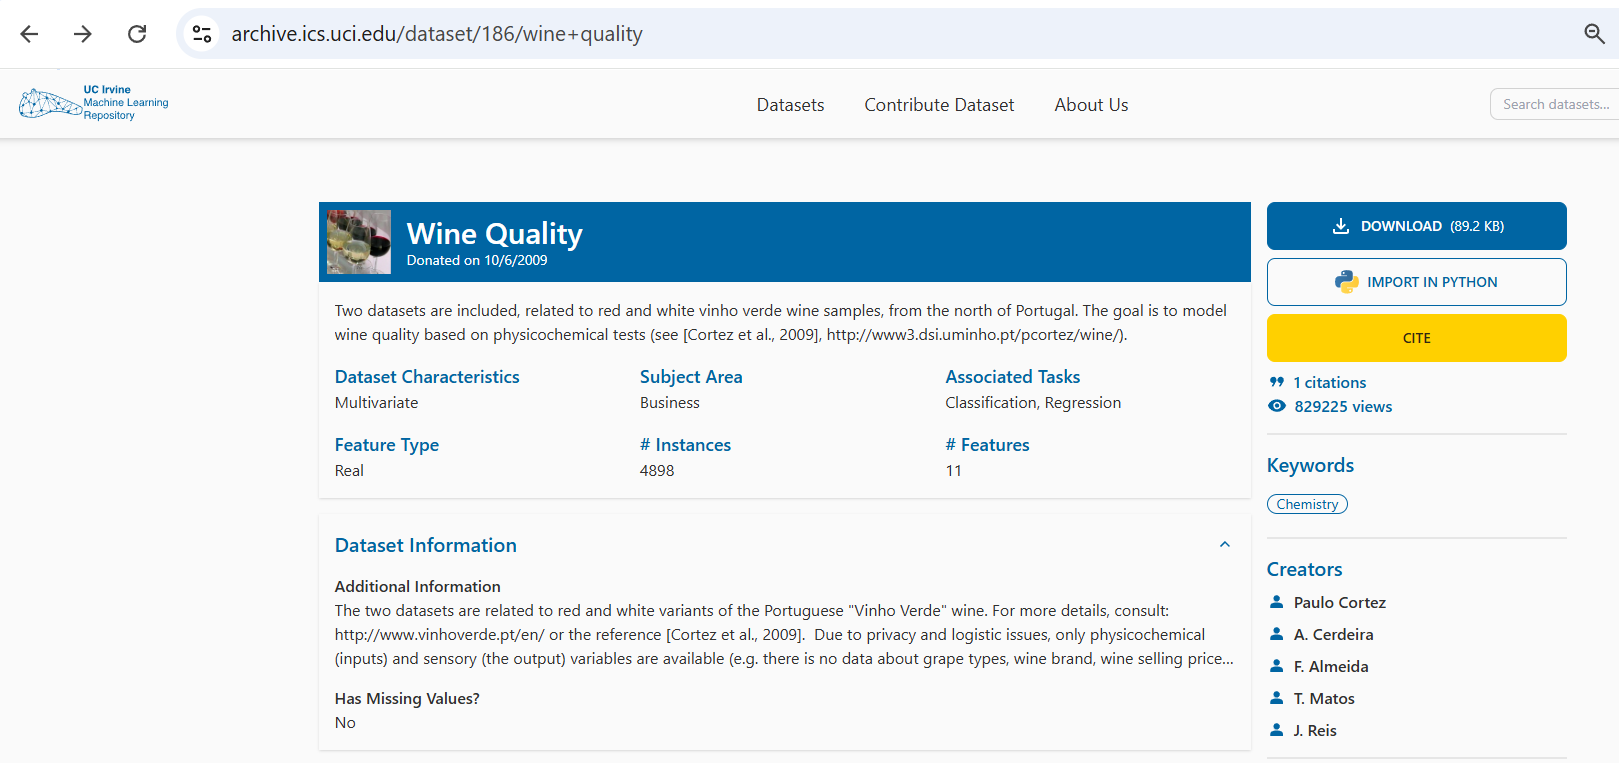

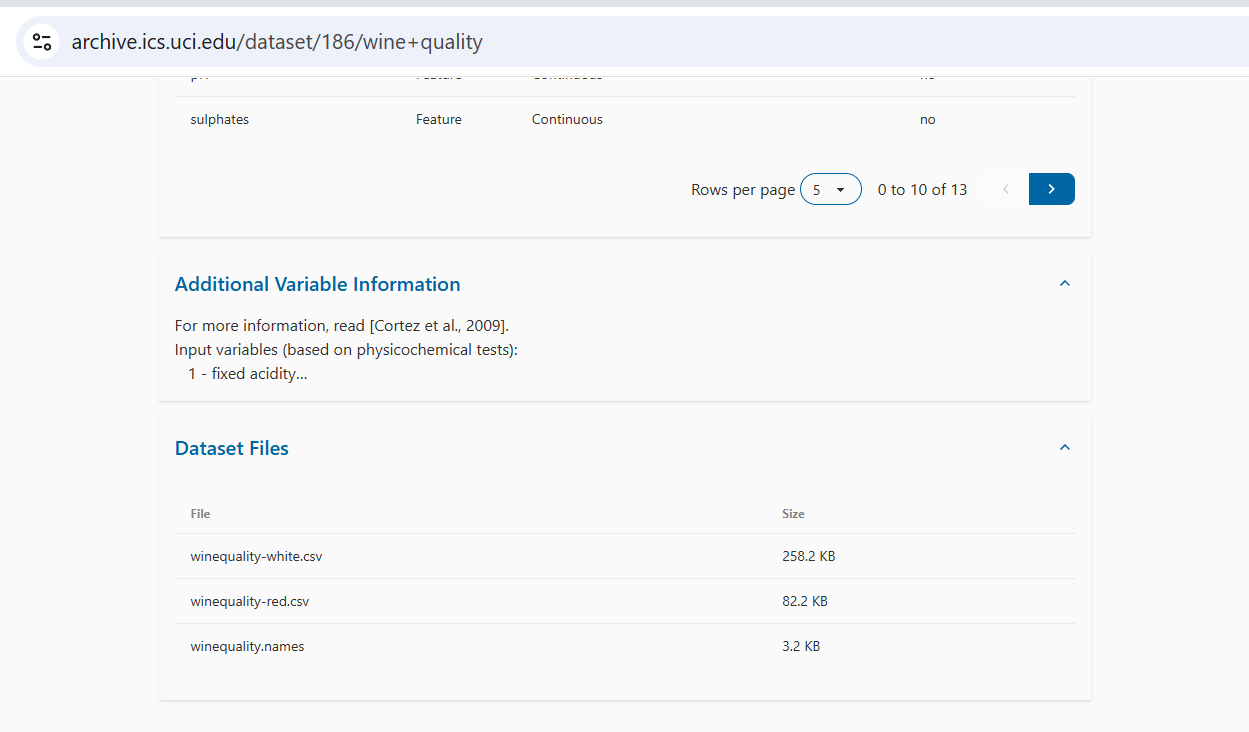

## Part 1: Προετοιμασία και Ανάλυση Δεδομένων

### 1. Επιλογή & Φόρτωση Dataset
#### Combine the two Wine Quality files (red + white wine) into a single, unified dataset.
#### Add a new binary column named color (0 = red, 1 = white) so that the specific wine type information is preserved

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση των δύο αρχείων (semicolon-separated)
# CSV στον ίδιο φάκελο με τα notebook

red   = pd.read_csv(r'C:\Users\panbe\Desktop\AI_Data_Factory_(PY)\datasets\winequality-red.csv',   sep=";") # Οι στήλες/features χωρίζονται με ; οπότε τις σπάμε
white = pd.read_csv(r'C:\Users\panbe\Desktop\AI_Data_Factory_(PY)\datasets\winequality-white.csv', sep=";")

# Προσθήκη στήλης color: 0 = red, 1 = white. Έχουμε 2 dataset. Σε κάθε ένα φτιάχνουμε μία στήλη που θα έχει το χρώμα του κρασιού για να τα ξεχωρίσουμε
red["color"]   = 0
white["color"] = 1

# Ενώνουμε τα δύο dataset σε ένα 
df = pd.concat([red, white], ignore_index=True) # Στην ένωση των dataset να αρχίσει η αρίθμηση από την αρχή
df

# Από την ένωση των 2 dataframes έχουμε 6497 rows × 13 columns

In [ ]:
print("Red shape   :", red.shape) # 1ο dataset
print("White shape :", white.shape) # 2ο dataset
print("Combined    :", df.shape)


In [ ]:
df.columns.to_list() # Επιβεβαίωση των χαρακτηριστικών των στηλών

In [ ]:
df.head() # Τσεκάρω πρώτες 5 γραμμές

In [ ]:
df.tail() # Τσεκάρω τελευταίες 5 γραμμές

In [ ]:
df.sample(10) # Τσεκάρω 10 τυχαίες γραμμές

In [ ]:
df.info() # Για να πάρω καλύτερα όλη την πληροφορία

# Δεν έχουμε κανένα NaN value

In [ ]:
df.isnull().sum() # Επιβεβαίωση ότι δεν έχουμε NaN values

In [ ]:
df.describe()     # statistics (mean, min, max κλπ)

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format) # Για να το διαβάζω καλύτερα
df.describe()

#pd.reset_option('display.float_format') #αν θέλω να το κάνω reset


#### Features ranges on different scales: total sulfur dioxide = 115.74, density = 0.99, free sulfur dioxide = 30.53 --> Will need StandardScaler after train/split and before SVM (SVMs measure distances, so a large-scale feature would dominate unless everything is normalized.)

#### Some Outliers: 
#### residual sugar --> q3 = 8.10 but max = 65.80 (x8 greater)
#### chlorides --> q3 = 0.07 but max = 0.61 (x8 greater)
#### free sulfur dioxide --> q3 = 41.00 but max = 289 (x7 greater)
#### total sulfur dioxide --> q3 = 156 but max = 440 (x3 greater)

#### The target quality --> mean = 5.82, median = 6, min = 3, max = 9, and 25%–75% sit at 5–6.
#### Η πλειοψηφία των κρασιών βαθμολογείται με 5 ή 6. Οπότε είναι συγκεντρωμένα στη μέση ή αλλιώς (clustered in the middle) --> ανισορροπία των κλάσεων (class imbalance) --> Βλέπε κάτωθι

In [ ]:
df["quality"].value_counts().sort_index() # Έχουμε τεράστια συγκέντρωση ratings στο 5,6 και λίγο λιγότερο στο 7. --> data imbalance

In [ ]:
counts = df["quality"].value_counts()
print("Most common class :", counts.idxmax(), "→", counts.max(), "wines")
print("Rarest class      :", counts.idxmin(), "→", counts.min(), "wines")
print("Imbalance ratio   :", round(counts.max() / counts.min(), 1), ": 1")

In [ ]:
df["quality"].value_counts(normalize=True).sort_index() * 100 # Σε ποσοστά --> data imbalance

In [ ]:
df.groupby("color")["quality"].value_counts().sort_index() # Ανά τύπο κρασιού

#### Barplot

In [ ]:

# Πλήθος κρασιών ανά quality, χωρισμένα σε red/white
ct = df.groupby(["quality", "color"]).size().unstack(fill_value=0)
ct.columns = ["Red", "White"]   # color 0 -> Red, 1 -> White

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor("lightgray")          # φόντο μέσα στο διάγραμμα μας
fig.patch.set_facecolor("lightgray")   # φόντο ολόκληρης της εικόνας

ct.plot(kind="bar",
        color=["darkred", "white"],     # red wine = darkred, white wine = white
        edgecolor="black", linewidth=0.8,  # μαύρο περίγραμμα ώστε να φαίνονται οι λευκές μπάρες
        ax=ax)

ax.set_title("Κατανομή Ποιότητας ανά τύπο κρασιού", fontweight="bold")
ax.set_xlabel("Quality score")
ax.set_ylabel("Number of wines")
plt.xticks(rotation=0)
ax.legend(title="Τύπος κρασιού")
ax.grid(axis="y", alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()

#### Μετατροπή σε δυαδικό πρόβλημα (binary target)
#### Λόγω της ανισορροπίας των κλάσεων που είδαμε πιο πάνω (7 κλάσεις, μόλις 5 κρασιά στο quality 9) και επειδή η ROC καμπύλη ορίζεται για δυαδικά προβλήματα, μετατρέπουμε το quality σε δυαδική μεταβλητή --> good
#### good = 1 αν quality >= 6 (καλό κρασί) --> Αν εδώ βάλω αντί για >=6, >=7 τότε το good = 1 είναι μόλις 19.70% σε αντίθεση με το >=6 που είναι 63.30%.
#### good = 0 αν quality < 6 (όχι καλό κρασί)
#### Αυτό δίνει μια πιο ισορροπημένη κατανομή (63% / 37%) όπως βλέπουμε κάτωθι και είναι το target που θα προβλέψουν τα μοντέλα στο Μέρος 2.

In [ ]:
df["good"] = (df["quality"] >= 6).astype(int)   # 1 = καλό (quality>=6), 0 = όχι καλό

print(df["good"].value_counts())                                   # σε απόλυτα νούμερα
print((df["good"].value_counts(normalize=True) * 100).round(1))    # σε ποσοστά

#### Pie Chart

In [ ]:

# Κατανομή του δυαδικού target (good)
counts = df["good"].value_counts().sort_index()   # sort_index() --> ώστε να μετρήσει πρώτα το 0 --> όχι καλό και μετά το 1 --> καλό
labels = ["Not good (quality < 6)", "Good (quality >= 6)"]

plt.figure(figsize=(6, 6))
plt.pie(counts,
        labels=labels,
        autopct="%1.1f%%",                 # δείχνει τα ποσοστά πάνω στις φέτες
        startangle=90,                     # ξεκινά από πάνω
        colors=["salmon", "green"],
        explode=(0.03, 0.03),              # μικρό κενό ανάμεσα στις φέτες
        wedgeprops={"edgecolor": "lightgray", "linewidth": 1.5})
plt.title("Κατανομή Δυαδικού Target (good)", fontweight="bold")
plt.axis("equal")                          # κρατάει τον κύκλο στρογγυλό
plt.tight_layout()
plt.show()

### 2. Διαχωρισμός του dataset

#### Train/Test Split (80/20)

In [ ]:
# Step 1 - Define X and y
X = df.drop(columns=["quality", "good"]) # Πρέπει να ξεχωρίσω τα δεδομένα εισόδου (τα χαρακτηριστικά με τα οποία θα τροφοδοτήσουμε το μοντέλο) από τη μεταβλητή-στόχο (αυτό που θέλουμε να προβλέψουμε)
                                         # Από την Χ πετάω το "quality" και το "good" αφού προέρχεται από την "quality". --> remove target and its source
y = df["good"]                           # Τι θέλω να προβλέψω                         
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures:")
print(X.columns.tolist())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify κρατά την αναλογία 63/37 --> stratify σε classification

print("=== Train/Test Split ===")
print(f"X_train: {X_train.shape}  ← 80% model learns from these")
print(f"X_test:  {X_test.shape}   ← 20% hidden from model")
print(f"y_train: {y_train.shape}  ← 80% true answers for training")
print(f"y_test:  {y_test.shape}   ← 20% true answers for evaluation")

# Έλεγχος ότι διατηρήθηκε η αναλογία των κλάσεων
print("\ny_train balance:\n", y_train.value_counts(normalize=True).round(3))
print("\ny_test balance:\n",  y_test.value_counts(normalize=True).round(3))

#### Εφαρμογή StandardScaler μετά το Train/Test Split

In [ ]:
# Με το StandardScaler κάθε feature κανονικοποιείται: z = (x - mean) / std
# Στο train οι στήλες έχουν ακριβώς mean ≈ 0 και std ≈ 1.
# Στο test εφαρμόζονται οι ΙΔΙΕΣ παράμετροι (mean/std του train), οπότε είναι κοντά αλλά όχι ακριβώς 0/1.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform ΜΟΝΟ στο train
X_test_scaled  = scaler.transform(X_test)         # μόνο transform στο test (ίδιες παράμετροι)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

In [ ]:
import numpy as np # Δοκιμή για να είμαι σίγουρος ότι είναι mean ≈ 0 και std ≈ 1 η μετατροπή
print("Train means:", np.round(X_train_scaled.mean(axis=0), 3))  # ≈ all 0
print("Train stds :", np.round(X_train_scaled.std(axis=0), 3))   # ≈ all 1

## Μέρος 2: Κατασκευή και Εκπαίδευση Μοντέλων

### 3. Υλοποίηση και εκπαίδευση μοντέλων

#### Εκπαιδεύστε έναν SVM με διαφορετικούς πυρήνες (linear, RBF). Επιπλέον βάζω και Random Forest, poly, sigmoid

##### Αφού κάνω Train/Test Split και Scaling εκπαιδεύω και αξιολογώ Random Forest με 5-fold cross-validation, SVM - rbf με 5-fold cross-validation και SVM - Linear με 5-fold cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Cross-validation: σπάμε το train set σε 5 ίσα κομμάτια (folds).
# Σε κάθε γύρο: 4 folds για εκπαίδευση, 1 fold (το 1/5 του train) για έλεγχο.
# Το fold ελέγχου αλλάζει σε κάθε γύρο, ώστε κάθε δείγμα του train να ελεγχθεί ακριβώς μία φορά.
# Στο τέλος παίρνουμε τον μέσο όρο των 5 σκορ --> np.mean(scores)
# το CV γίνεται ΜΟΝΟ στο X_train. Το πραγματικό X_test (20%) μένει κρυμμένο για την τελική αξιολόγηση --> Βλέπε (Μέρος 2.4).

# Εκπαίδευση και αξιολόγηση Random Forest με 5-fold cross-validation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5)  # Cross-validation
rf_accuracy = np.mean(rf_scores)

# Εκπαίδευση και αξιολόγηση SVM με 5-fold cross-validation με rbf
svm_rbf = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", random_state=42))])
svm_scores1 = cross_val_score(svm_rbf, X_train, y_train, cv=5)
svm_accuracy1 = np.mean(svm_scores1)

# Εκπαίδευση και αξιολόγηση SVM με 5-fold cross-validation με linear
svm_linear = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear", random_state=42))])
svm_scores2 = cross_val_score(svm_linear, X_train, y_train, cv=5)
svm_accuracy2 = np.mean(svm_scores2)

# Εκπαίδευση και αξιολόγηση SVM με 5-fold cross-validation με poly
svm_poly = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="poly", random_state=42))])
svm_scores3 = cross_val_score(svm_poly, X_train, y_train, cv=5)
svm_accuracy3 = np.mean(svm_scores3)

# Εκπαίδευση και αξιολόγηση SVM με 5-fold cross-validation με sigmoid
svm_sigmoid = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="sigmoid", random_state=42))])
svm_scores4 = cross_val_score(svm_sigmoid, X_train, y_train, cv=5)
svm_accuracy4 = np.mean(svm_scores4)

# Εκτύπωση αποτελεσμάτων
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"SVM Accuracy with rbf: {svm_accuracy1:.4f}")
print(f"SVM Accuracy with linear: {svm_accuracy2:.4f}")
print(f"SVM Accuracy with poly: {svm_accuracy3:.4f}")
print(f"SVM Accuracy with sigmoid: {svm_accuracy4:.4f}")


#### Εκπαιδεύστε ένα Δυαδικό Δέντρο Απόφασης με διαφορετικά βάθη δέντρου

In [ ]:
# Δέντρο Απόφασης με διαφορετικά βάθη (max_depth)
# Για κάθε βάθος -> 5-fold cross-validation στο X_train
# Τα δέντρα ΔΕΝ χρειάζονται scaling -> χρησιμοποιούμε το ΑΡΧΙΚΟ X_train
# Μεγάλο βάθος → Overfitting | Μικρό βάθος → Underfitting (απλοϊκό)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

depths = range(1, 16)        # δοκιμάζουμε βάθη από 1 έως 15
cv_scores = []               # εδώ κρατάμε το μέσο CV accuracy κάθε βάθους

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42) # φτιάχνει δέντρο με βάθος d
    scores = cross_val_score(tree, X_train, y_train, cv=5)      # 5-fold CV στο X_train
    cv_scores.append(scores.mean())                             # αποθηκεύει τον μέσο όρο των 5 folds
    print(f"max_depth={d:2d} | CV accuracy={scores.mean():.4f}")

# Το βάθος με το καλύτερο CV accuracy
best_depth_cv = list(depths)[int(np.argmax(cv_scores))]
print(f"\nBest depth (CV): {best_depth_cv}  |  CV accuracy: {max(cv_scores):.4f}")

##### Το CV accuracy μεγιστοποιείται στο max_depth=15 (0.7516), όμως η βελτίωση μετά το βάθος max_depth=6 είναι ελάχιστη (~1.2%) μέχρι το max_depth=15.
##### Παράλληλα, στο train/test τα βαθιά δέντρα κάνουν έντονο overfitting (π.χ. max_depth=15: train ≈ 0.98 vs test ≈ 0.77).
##### Θα επιλέξουμε το βάθος με κριτήριο την καλή ισορροπία μεταξύ test accuracy και overfitting (όχι απλώς το υψηλότερο test accuracy). Επιλέγουμε λοιπόν ένα μέτριο βάθος, max_depth=8: CV accuracy 0.745 και test accuracy 0.757, με μικρό train–test gap (train ≈ 0.835 vs test ≈ 0.757) — δηλαδή καλή απόδοση χωρίς έντονο overfitting.
##### Η τελική επιλογή των υπερπαραμέτρων θα γίνει στο Μέρος 3 με GridSearch.

In [ ]:
# Train vs Test accuracy per depth (για να φανεί το overfitting)

train_scores = []
test_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

for d, tr, te in zip(depths, train_scores, test_scores):
    print(f"max_depth={d:2d} | train_acc={tr:.3f} | test_acc={te:.3f}")


In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker='o', label="Train accuracy")
plt.plot(depths, test_scores,  marker='s', label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Επίδραση του max_depth στο Decision Tree")
plt.legend()
plt.grid(True)
plt.show()


##### Για βάθη 1-3: Οι 2 γραμμές βρίσκονται η μία πάνω στην άλλη και χαμηλά --> underfit
##### Για βάθος 4: Οι 2 γραμμές αρχίζουν να απομακρύνονται η μία από την άλλη
##### Για βάθη 4-15: Η απόσταση αυξάνεται. Η μπλε γραμμή (Training) ανεβαίνει συνεχώς, ενώ η πορτοκαλί (Test) μένει σταθερή (~0.77) --> overfit
##### Συμπέρασμα: Επιλέγουμε μέτριο βάθος (max_depth=8): καλή ισορροπία ανάμεσα σε test accuracy (0.757) και μικρό train–test gap, αποφεύγοντας το overfitting των βαθύτερων δέντρων.

In [ ]:
# Τελικό μοντέλο: μέτριο βάθος (καλό test accuracy, μικρό overfitting)
best_depth = 8
tree_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree_best.fit(X_train, y_train)

print(f"Decision Tree (depth={best_depth})")
print(f"  Train accuracy: {accuracy_score(y_train, tree_best.predict(X_train)):.3f}")
print(f"  Test  accuracy: {accuracy_score(y_test,  tree_best.predict(X_test)):.3f}")

# Για οπτικοποίηση --> ρηχό δέντρο (depth=3) ώστε να είναι ευανάγνωστο.
# (Το τελικό μοντέλο είναι depth=8, αλλά είναι μεγάλο για να φανεί καθαρά.)
tree_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    tree_viz,
    feature_names=X_train.columns,       # τα ονόματα των 12 χαρακτηριστικών
    class_names=["Not good", "Good"],    # 0 = Not good, 1 = Good
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Δέντρο Απόφασης (οπτικοποίηση με max_depth=3 για ευκρίνεια)")
plt.show()


### 4. Αξιολόγηση των μοντέλων

#### Υπολογίστε την ακρίβεια (accuracy), τον δείκτη F1-score, την καμπύλη ROC και τον πίνακα σύγχυσης για κάθε μοντέλο.

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Τα 3 τελικά μοντέλα.
# Βάζω στον SVC probability=True για να δίνει predict_proba (ROC).
final_models = {
    "SVM (linear)":  Pipeline([("scaler", StandardScaler()),
                               ("svm", SVC(kernel="linear", probability=True, random_state=42))]),
    "SVM (rbf)":     Pipeline([("scaler", StandardScaler()),
                               ("svm", SVC(kernel="rbf", probability=True, random_state=42))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
}

predictions = {}   # προβλέψεις (0/1) κάθε μοντέλου
probabilities = {} # πιθανότητες της θετικής κλάσης (good=1) -> για ROC

for name, model in final_models.items():
    model.fit(X_train, y_train)
    predictions[name]    = model.predict(X_test) # --> Το εκπαιδευμένο μοντέλο προβλέπει την κλάση (0 ή 1). Υπάρχει εσωτερικά ένα threshold εδώ. Αν P(1) ≥ 0.5 → 1 (Good), else → 0 (Not good).
    probabilities[name]  = model.predict_proba(X_test)[:, 1] # --> Το εκπαιδευμένο μοντέλο προβλέπει την πιθανότητα P(0) = Πιθανότητα το κρασί να είναι στην κλάση 0 (Not good), P(1) = Πιθανότητα το κρασί να είναι στην κλάση 1 (Good). Με το [:, 1] Παίρνουμε την P(1) κάθε φορά. Φέρνει απλά την P(1) όσο είναι πχ P(1) = 0.40
    print(f"{name}: trained ΟΚ")

In [ ]:
for name in final_models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    print(f"\n=== {name} ===")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}") #--> Από το σύνολο όλων των κρασιών, τι ποσοστό (%) ταξινομήσαμε σωστά
    print(f"Precision : {precision_score(y_test, y_pred):.4f}") #--> Από όλα τα κρασιά που το μοντέλο προέβλεψε ως Καλά, τι ποσοστό (%) ήταν στην πραγματικότητα Καλά
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}") #--> Από όλα τα κρασιά που ήταν στην πραγματικότητα Καλά μέσα στο dataset, τι ποσοστό (%) κατάφερε το μοντέλο να εντοπίσει σωστά
    print(f"F1-score  : {f1_score(y_test, y_pred):.4f}") #--> Ο F1-Score συνδυάζει Precision και Recall — ο αρμονικός μέσος όρος τους (τιμωρεί όταν ένα από τα δύο νούμερα είναι πολύ χαμηλό)
    print(f"AUC       : {roc_auc_score(y_test, y_prob):.4f}") #--> Δείκτης AUC — μετράει πόσο καλά διαχωρίζει το μοντέλο τις δύο κλάσεις (Καλό vs Μη Καλό κρασί) --> 0.5 = random, 1.0 = perfect
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=["Not good (0)", "Good (1)"]))

##### Confusion Matrix για κάθε μοντέλο: SVM (linear), SVM (rbf), Decision Tree

In [ ]:
for name in final_models:
    cm = confusion_matrix(y_test, predictions[name])
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not good (0)", "Good (1)"],
                yticklabels=["Not good (0)", "Good (1)"])
    plt.xlabel("Predicted label", fontweight="bold")
    plt.ylabel("True label", fontweight="bold")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

##### Συμπεράσματα από τους Πίνακες Σύγχυσης (Confusion Matrices)
##### γραμμές = πραγματικές κλάσεις, στήλες = προβλέψεις. Η διαγώνιος = σωστές προβλέψεις.
##### - **SVM (rbf):** έχει τα περισσότερα σωστά Good (TP=722) και τα λιγότερα χαμένα Good (FN=101). Είναι το μοντέλο που εντοπίζει καλύτερα τα καλά κρασιά.
##### - **Decision Tree:** εντοπίζει καλύτερα τα Not good (TN=306, τα περισσότερα) και κάνει τα λιγότερα λάθος-θετικά (FP=171), αλλά χάνει περισσότερα καλά κρασιά (FN=145).
##### - **SVM (linear):** το ασθενέστερο — λιγότερα σωστά Not good (TN=261) και τα περισσότερα FP (216).
##### Κοινό μοτίβο και στα 3 μοντέλα: μπερδεύουν περισσότερο την κλάση **Not good** (πολλά FP) παρά την κλάση Good. Αυτό οφείλεται στην **ανισορροπία** (823 Good vs 477 Not good στο test) — τα μοντέλα "προτιμούν" να προβλέπουν την πλειοψηφική κλάση (Good).
##### Συνολικά, ο **SVM (rbf)** έχει την καλύτερη ισορροπία: τα περισσότερα σωστά Good TP και τα λιγότερα FN, που εξηγεί και το υψηλότερο F1/AUC.

##### ROC curves για κάθε μοντέλο: SVM (linear), SVM (rbf), Decision Tree

In [ ]:
plt.figure(figsize=(7, 6))
colors = {"SVM (linear)": "green", "SVM (rbf)": "blue", "Decision Tree": "darkorange"}

for name in final_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {auc_score:.4f})')

# Random classifier (διαγώνιος)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — SVM (linear, rbf) vs Decision Tree')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### **Συμπεράσματα από τις καμπύλες ROC:**
##### - Και τα 3 μοντέλα είναι σαφώς πάνω από τη διαγώνιο (τυχαίο μοντέλο, AUC=0.50), άρα αποδίδουν σαφώς καλύτερα από το τυχαίο.
##### - Ο **SVM (rbf)** έχει την υψηλότερη καμπύλη (πιο κοντά στην πάνω-αριστερή γωνία) και το μεγαλύτερο **AUC = 0.840** → διαχωρίζει καλύτερα τα Good από τα Not good κρασιά.
##### - Ο **SVM (linear)** (AUC=0.800) και το **Decision Tree** (AUC=0.795) είναι σχεδόν ισοδύναμα, αρκετά πιο κάτω από τον RBF.
##### - Το πλεονέκτημα του RBF είναι μεγαλύτερο στην περιοχή χαμηλού FPR (~0.1–0.3): για το ίδιο ποσοστό λανθασμένων θετικών, πιάνει περισσότερα πραγματικά Good.
##### - Συμπέρασμα: το AUC επιβεβαιώνει τα υπόλοιπα metrics — ο **SVM (rbf) είναι το καλύτερο μοντέλο**.

#### **Συγκρίνετε την απόδοση των δύο μεθόδων και εξηγήστε ποιο μοντέλο αποδίδει καλύτερα και γιατί:**
##### Σύγκριση των δύο μεθόδων (SVM vs Decision Tree) με βάση τα παραπάνω
##### Αποτελέσματα στο test set:
##### | Μοντέλο | Accuracy | F1 | AUC |
##### | SVM (linear) | 0.735 | 0.801 | 0.800 |
##### | SVM (rbf) | 0.773 | 0.830 | 0.840 |
##### | Decision Tree (depth=8) | 0.757 | 0.811 | 0.795 |
##### **Καλύτερο μοντέλο: SVM με RBF kernel.**
##### Σύγκριση των δύο μεθόδων:
##### - Στον **SVM**, ο RBF kernel (accuracy 0.773) υπερτερεί του linear (0.735).
##### - Ο **linear kernel** χαράζει ένα **ευθύ** σύνορο απόφασης (Decision boundary): χωρίζει τα "Καλά" από τα "Μη Καλά" κρασιά με μία ίσια γραμμή (επίπεδο σε πολλές διαστάσεις). Αυτό δουλεύει μόνο αν οι δύο κλάσεις διαχωρίζονται γραμμικά.
##### - Ο **RBF kernel** χαράζει **καμπύλο, εύκαμπτο** σύνορο, οπότε μπορεί να διαχωρίσει κλάσεις που "μπλέκονται" μεταξύ τους και δεν χωρίζονται με ευθεία.
##### - Στα δεδομένα του κρασιού, η σχέση των χημικών χαρακτηριστικών με την ποιότητα **δεν είναι γραμμική**: π.χ. η ποιότητα δεν αυξάνεται απλώς όσο ανεβαίνει ένα χαρακτηριστικό — εξαρτάται από **συνδυασμούς** χαρακτηριστικών (αλκοόλ μαζί με volatile acidity, sulphates κ.λπ.).
##### - Γι' αυτό το **καμπύλο σύνορο του RBF ταιριάζει καλύτερα** στα δεδομένα και πετυχαίνει υψηλότερο accuracy, F1 και AUC από τον linear.
##### - Το γεγονός ότι ο RBF κερδίζει (αλλά όχι με τεράστια διαφορά) δείχνει ότι τα δεδομένα είναι **μερικώς** μη γραμμικά: ο linear πιάνει ένα μεγάλο μέρος του μοτίβου, αλλά ο RBF προσθέτει την ευελιξία που χρειάζεται για τα πιο "μπερδεμένα" σημεία.
##### - Συγκρίνοντας την **καλύτερη εκδοχή του SVM (rbf) με το Decision Tree**: ο SVM (rbf) αποδίδει καλύτερα σε όλες τις μετρικές — accuracy 0.773 vs 0.757, F1 0.830 vs 0.811, και κυρίως AUC 0.840 vs 0.795.
##### Γιατί ο SVM (rbf) είναι καλύτερος:
##### - Το υψηλότερο **AUC (0.840)** σημαίνει ότι διαχωρίζει καλύτερα τις δύο κλάσεις ("Καλά" vs "Μη Καλά") ανεξάρτητα από το κατώφλι απόφασης.
##### - Το **Decision Tree**, αν και ανταγωνιστικό σε accuracy/F1, έχει το χαμηλότερο AUC και τείνει σε overfitting στα μεγάλα βάθη (όπως φάνηκε στο πείραμα βαθών: train ≈ 0.98 vs test ≈ 0.77).
##### Σημείωση: επειδή οι κλάσεις είναι ανισόρροπες (63/37), τα **F1-score** και **AUC** είναι πιο αξιόπιστα κριτήρια από το σκέτο accuracy — και ο SVM (rbf) προηγείται και στα δύο.

## Μέρος 3: Βελτιστοποίηση και Σύγκριση

### 5. Βελτιστοποίηση υπερπαραμέτρων

#### Χρησιμοποιήστε Grid Search ή Random Search για την εύρεση των βέλτιστων παραμέτρων των μοντέλων.

#### Βήμα 1: Συνδιασμένο SVM GridSearch (linear + rbf)

In [ ]:
import time
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

RANDOM_STATE = 42

# 5-fold stratified CV (κρατά την αναλογία κλάσεων)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Pipeline: Scaler -> SVC (χωρίς probability=True για ταχύτητα στο tuning)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(random_state=RANDOM_STATE))
])

# Grid = λίστα 2 dicts:
#  - linear: μόνο C (δεν έχει gamma)
#  - rbf: C + gamma
param_grid = [
    {"svm__kernel": ["linear"], "svm__C": [0.1, 1, 10, 100]},
    {"svm__kernel": ["rbf"],    "svm__C": [0.1, 1, 10, 100],
                                "svm__gamma": [0.001, 0.01, 0.1, 1, "scale"]},
]

start_time = time.time()
gs_svm = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1",        # F1 της θετικής κλάσης (good=1) — κατάλληλο για imbalanced
    cv=cv,               # Εδώ μπαίνει το cv = 5
    n_jobs=-1,           # χρήση όλων των πυρήνων
    return_train_score=True
)
gs_svm.fit(X_train, y_train)
grid_time = time.time() - start_time
print(f"GridSearch χρόνος: {grid_time:.1f}s\n")

# Αποτελέσματα tuning
print("Best params:", gs_svm.best_params_)
print(f"Best CV F1 : {gs_svm.best_score_:.4f}")

# Τελικό tuned μοντέλο -> αξιολόγηση στο test set
best_svm = gs_svm.best_estimator_
y_pred = best_svm.predict(X_test)
print(f"\nTuned SVM — Train accuracy: {accuracy_score(y_train, best_svm.predict(X_train)):.4f}")
print(f"Tuned SVM — Test  accuracy: {accuracy_score(y_test,  best_svm.predict(X_test)):.4f}")
print(f"Tuned SVM — Test  F1      : {f1_score(y_test,  best_svm.predict(X_test)):.4f}")

#### Βήμα 2: Decision Tree GridSearch

In [ ]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Grid για το Δέντρο — περιλαμβάνει και παραμέτρους που ελέγχουν το overfitting:
#   - max_depth: μέγιστο βάθος
#   - min_samples_leaf: ελάχιστα δείγματα ανά φύλλο (για τον περιορισμό overfitting)
#   - min_samples_split: ελάχιστα δείγματα για να γίνει split
#   - criterion: μέτρο ποιότητας split (gini/entropy)
param_grid_tree = {
    "max_depth":         [4, 6, 8, 10, 12],
    "min_samples_leaf":  [5, 10, 20, 50],
    "min_samples_split": [2, 10, 20],
    "criterion":         ["gini", "entropy"],
}

start_time = time.time()
gs_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_tree,
    scoring="f1",
    cv=cv,                # ίδιο StratifiedKFold(5) με το SVM
    n_jobs=-1,
    return_train_score=True
)
gs_tree.fit(X_train, y_train)
print(f"GridSearch χρόνος: {time.time()-start_time:.1f}s\n")

print("Best params:", gs_tree.best_params_)
print(f"Best CV F1 : {gs_tree.best_score_:.4f}")

# Τελικό tuned δέντρο -> αξιολόγηση
best_tree = gs_tree.best_estimator_
print(f"\nTuned Tree — Train accuracy: {accuracy_score(y_train, best_tree.predict(X_train)):.4f}")
print(f"Tuned Tree — Test  accuracy: {accuracy_score(y_test,  best_tree.predict(X_test)):.4f}")
print(f"Tuned Tree — Test  F1      : {f1_score(y_test,  best_tree.predict(X_test)):.4f}")

##### Decision Tree Untuned (depth=8) Train accuracy: 0.835, Test  accuracy: 0.757 --> Gap 0.078
##### Decision Tree Tuned (GridSearch) Train accuracy: 0.769, Test  accuracy: 0.751 --> Gap 0.019
##### Το Test accuracy μένει ουσιαστικά ίδιο, χωρίς όμως το overfitting

#### Βήμα 3: Random Search 

##### Το GridSearch εξετάζει εξαντλητικά όλους τους συνδυασμούς. Το RandomSearch δοκιμάζει έναν τυχαίο υποσύνολο (n_iter), οπότε είναι γρηγορότερο και συχνά βρίσκει παρόμοιες παραμέτρους.

In [ ]:
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from scipy.stats import loguniform   # για συνεχείς (log) κατανομές

# RandomSearch: δειγματοληπτεί τυχαία από συνεχείς περιοχές (όχι σταθερές τιμές όπως το Grid)
pipe_rs = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", random_state=RANDOM_STATE))
])

param_dist = {
    "svm__C":     loguniform(1e-1, 1e2),   # C από 0.1 έως 100 (συνεχές, log scale)
    "svm__gamma": loguniform(1e-3, 1e1),   # gamma από 0.001 έως 10 (συνεχές)
}

start_time = time.time()
rs_svm = RandomizedSearchCV(
    pipe_rs,
    param_distributions=param_dist,
    n_iter=20,               # δοκιμάζει 20 τυχαίους συνδυασμούς (όχι όλους)
    scoring="f1",
    cv=cv,                   # ίδιο StratifiedKFold(5)
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True
)
rs_svm.fit(X_train, y_train)
random_time = time.time() - start_time
print(f"RandomSearch χρόνος: {random_time:.1f}s\n")

print("Best params:", rs_svm.best_params_)
print(f"Best CV F1 : {rs_svm.best_score_:.4f}")

best_svm_rs = rs_svm.best_estimator_
print(f"\nRandomSearch SVM — Train accuracy: {accuracy_score(y_train, best_svm_rs.predict(X_train)):.4f}")
print(f"RandomSearch SVM — Test Accuracy: {accuracy_score(y_test, best_svm_rs.predict(X_test)):.4f}")
print(f"RandomSearch SVM — Test F1      : {f1_score(y_test,  best_svm_rs.predict(X_test)):.4f}")

##### Grid-vs-Random comparison table

In [ ]:
summary = pd.DataFrame([
    {"Μέθοδος": "GridSearch SVM",
     "C": gs_svm.best_params_["svm__C"],
     "gamma": gs_svm.best_params_["svm__gamma"],
     "Test Acc": accuracy_score(y_test, best_svm.predict(X_test)),
     "Χρόνος (s)": grid_time},
    {"Μέθοδος": "RandomSearch SVM",
     "C": round(rs_svm.best_params_["svm__C"], 3),
     "gamma": round(rs_svm.best_params_["svm__gamma"], 3),
     "Test Acc": accuracy_score(y_test, best_svm_rs.predict(X_test)),
     "Χρόνος (s)": random_time},
]).set_index("Μέθοδος").round(4)
print(summary)

#### Αναφέρετε τις καλύτερες υπερπαραμέτρους και την αντίστοιχη ακρίβεια. - Χωρίς AUC

In [ ]:
results = pd.DataFrame([
    {"Μοντέλο": "SVM (GridSearch)",
     "Βέλτιστες παράμετροι": "rbf, C=1, gamma=1",
     "Test Acc": accuracy_score(y_test, best_svm.predict(X_test)),
     "Test F1":  f1_score(y_test, best_svm.predict(X_test))},
    {"Μοντέλο": "SVM (RandomSearch)",
     "Βέλτιστες παράμετροι": "rbf, C=2.335, gamma=1.383",
     "Test Acc": accuracy_score(y_test, best_svm_rs.predict(X_test)),
     "Test F1":  f1_score(y_test, best_svm_rs.predict(X_test))},
    {"Μοντέλο": "Decision Tree (GridSearch)",
     "Βέλτιστες παράμετροι": "entropy, depth=10, leaf=50",
     "Test Acc": accuracy_score(y_test, best_tree.predict(X_test)),
     "Test F1":  f1_score(y_test, best_tree.predict(X_test))},
]).set_index("Μοντέλο")

results.style.format({"Test Acc": "{:.4f}", "Test F1": "{:.4f}", "Test AUC": "{:.4f}"})

#### Αναφέρετε τις καλύτερες υπερπαραμέτρους και την αντίστοιχη ακρίβεια. - Με AUC

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Ξαναφτιάχνω μόνο όμως τα τελικά tuned SVM με probability=True (για το AUC).
# Στο Βήμα 1 (SVM GridSearch) και Βήμα 3 (RandomSearch) δεν βάλαμε probability=True για να τρέξει πιο γρήγορα.
# Στο Βήμα 2 (Decision Tree GridSearch) δεν χρειάστηκε έτσι και αλλιώς γιατί το predict_proba υπάρχει By default.

svm_grid_final = Pipeline([("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1, gamma=1, probability=True, random_state=RANDOM_STATE))
]).fit(X_train, y_train)

svm_rand_final = Pipeline([("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=2.335, gamma=1.383, probability=True, random_state=RANDOM_STATE))
]).fit(X_train, y_train)

tree_final = best_tree   # το δέντρο έχει predict_proba από default

def row(name, params, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {"Μοντέλο": name, "Βέλτιστες παράμετροι": params,
            "Test Acc": accuracy_score(y_test, y_pred),
            "Test F1":  f1_score(y_test, y_pred),
            "Test AUC": roc_auc_score(y_test, y_prob)}

results = pd.DataFrame([
    row("SVM (GridSearch)",           "rbf, C=1, gamma=1",          svm_grid_final),
    row("SVM (RandomSearch)",         "rbf, C=2.335, gamma=1.383",  svm_rand_final),
    row("Decision Tree (GridSearch)", "entropy, depth=10, leaf=50", tree_final),
]).set_index("Μοντέλο")

results.style.format({"Test Acc": "{:.4f}", "Test F1": "{:.4f}", "Test AUC": "{:.4f}"})

### 6. Σχολιασμός των αποτελεσμάτων

#### **Ποιο μοντέλο είχε την καλύτερη απόδοση και γιατί;**

##### Καλύτερο μοντέλο: SVM (rbf) μετά από RandomSearch — Test Accuracy 0.8015, F1 0.8532, AUC 0.8594.
##### Σύγκριση όλων των tuned μοντέλων (test set):
##### - SVM (RandomSearch): rbf, C=2.335, gamma=1.383 → Acc 0.8015, F1 0.8532, AUC 0.8594  ← καλύτερο
##### - SVM (GridSearch): rbf, C=1, gamma=1 → Acc 0.7915, F1 0.8456, AUC 0.8547
##### - Σημείωση: στο GridSearch ο linear kernel δοκιμάστηκε αλλά απορρίφθηκε υπέρ του rbf — επιβεβαιώνοντας το αποτέλεσμα του Μέρους 2 ότι ο rbf είναι καλύτερος για αυτά τα (μη γραμμικά) δεδομένα.
##### - Decision Tree (GridSearch): entropy, depth=10, leaf=50 → Acc 0.7508, F1 0.8076, AUC 0.8113

##### Γιατί ο SVM (rbf) είναι ο καλύτερος:
##### - Σε όλη την άσκηση (και untuned και tuned) ο SVM με RBF kernel πετυχαίνει την υψηλότερη ακρίβεια και το υψηλότερο F1 και AUC.
##### - Ο RBF kernel χαράζει καμπύλο σύνορο απόφασης, που ταιριάζει καλύτερα στη μη γραμμική σχέση μεταξύ των χημικών χαρακτηριστικών και της ποιότητας του κρασιού.
##### - Το υψηλότερο AUC (0.8594) δείχνει ότι ο SVM (rbf) διαχωρίζει καλύτερα τις δύο κλάσεις (Καλό vs Μη Καλό) ανεξάρτητα από το κατώφλι — και επειδή οι κλάσεις είναι ανισόρροπες (63/37), το AUC είναι από τα πιο αξιόπιστα κριτήρια.
##### - Το Decision Tree, αν και ανταγωνιστικό, έχει χαμηλότερο accuracy/F1 και το χαμηλότερο AUC (0.8113) — δηλαδή μικρότερη ικανότητα διαχωρισμού των κλάσεων.

##### **Σημείωση για το overfitting (train vs test):**
##### - Tuned SVM (rbf, C=1, γ=1): Train 0.9446, Test 0.7915 → Gap 0.1530
##### - Tuned Tree (depth=10, leaf=50): Train 0.7699, Test 0.7508 → Gap 0.0191
##### - Ο SVM έχει υψηλότερο accuracy/AUC αλλά **μεγαλύτερο overfitting** (το gamma κάνει το σύνορο πιο ευέλικτο).
##### - Το Tree έχει χαμηλότερο accuracy αλλά **γενικεύει πιο τίμια** (πολύ μικρό gap, χάρη στο min_samples_leaf=50).

##### **Συμπέρασμα:** Με κριτήριο την απόδοση στο test set (accuracy, F1 και AUC), ο SVM (rbf) είναι το καλύτερο μοντέλο. Αν προτεραιότητα ήταν η ελάχιστη υπερπροσαρμογή (overfitting), το tuned Decision Tree θα ήταν προτιμότερο λόγω του πολύ μικρού train–test gap.

#### **Πώς επηρέασε η επιλογή των παραμέτρων την ακρίβεια**;

##### SVM — επίδραση των C και gamma:
##### - Το gamma ελέγχει πόσο "ευέλικτο" (καμπύλο) είναι το σύνορο του RBF. Μεγάλο gamma → πιο τοπικό, πιο πολύπλοκο σύνορο.
##### - Untuned (gamma="scale"): Test 0.7731. Μετά το tuning (gamma=1): Test 0.7915 → +1.8% βελτίωση στην ακρίβεια.
##### - Όμως το μεγαλύτερο gamma αύξησε και το overfitting: το train ανέβηκε στο 0.9446 ενώ το test στο 0.7915 (gap 0.153). Δηλαδή το gamma βελτίωσε το test accuracy αλλά έκανε το μοντέλο να ταιριάζει πιο πολύ στο train.


In [ ]:
from sklearn.metrics import accuracy_score

# Σύγκριση overfitting: untuned vs tuned SVM (rbf)
# Δείχνει ότι το gamma=1 αύξησε το overfitting σε σχέση με το untuned (gamma="scale").
untuned_svm = Pipeline([("scaler", StandardScaler()),
                        ("svm", SVC(kernel="rbf", random_state=RANDOM_STATE))]).fit(X_train, y_train)

tr = accuracy_score(y_train, untuned_svm.predict(X_train))
te = accuracy_score(y_test,  untuned_svm.predict(X_test))
print(f"Untuned SVM (rbf, gamma=scale) — Train: {tr:.4f} | Test: {te:.4f} | Gap: {tr-te:.4f}")
print(f"(Σύγκριση: Tuned SVM gamma=1 → Train 0.9446 | Test 0.7915 | Gap 0.1530)")

##### - Το **C** (penalty στα λάθη) έμεινε στο 1 — μέτρια τιμή, ισορροπία ανάμεσα σε αυστηρότητα και γενίκευση.

##### Decision Tree — επίδραση των max_depth και min_samples_leaf:
##### - Untuned (depth=8): Train 0.835 / Test 0.757 → gap 0.078 (κάποιο overfitting).
##### - Tuned (depth=10, min_samples_leaf=50): Train 0.770 / Test 0.751 → gap 0.019.
##### - Το min_samples_leaf=50 ήταν καθοριστικό: αναγκάζει κάθε φύλλο να έχει ≥50 δείγματα, οπότε το δέντρο δεν κάνει μικρά splits που "απομνημονεύουν" θόρυβο. Έτσι **εξαλείφθηκε το overfitting** (gap 0.078 → 0.019), με σχεδόν ίδιο test accuracy.
##### - Δηλαδή εδώ οι παράμετροι δεν αύξησαν το accuracy, αλλά βελτίωσαν τη γενίκευση (μικρότερο gap).

##### Grid Search vs Random Search:
##### - Το GridSearch δοκίμασε μόνο σταθερές τιμές (C ∈ {0.1,1,10,100}, gamma ∈ {0.001,0.01,0.1,1,scale}) → βρήκε C=1, gamma=1, Test 0.7915.
##### - Το RandomSearch δειγματολήπτησε από συνεχείς περιοχές → βρήκε C=2.335, gamma=1.383 (τιμές ανάμεσα στα σημεία του grid), Test 0.8015 → ελαφρώς καλύτερο.
##### - Επιπλέον το RandomSearch ήταν γρηγορότερο (12.5s vs 18.2s), αφού δοκίμασε λιγότερους (20 τυχαίους) συνδυασμούς αντί όλων.

##### **Συμπέρασμα:** Η επιλογή των υπερπαραμέτρων επηρεάζει είτε την **ακρίβεια** (gamma στον SVM → +1.8%), είτε το **overfitting** (min_samples_leaf στο δέντρο → gap 0.078→0.019). Το RandomSearch, χάρη στη συνεχή δειγματοληψία, βρήκε ελαφρώς καλύτερες τιμές από το GridSearch, πιο γρήγορα.

#### **Τελικά Συμπεράσματα - Σύνοψη**

##### Στην παρούσα εργασία ταξινομήσαμε την ποιότητα κρασιών (Καλό vs Μη Καλό) χρησιμοποιώντας SVM (linear, rbf) και Decision Tree στο συνδυασμένο dataset (6.497 κρασιά, 12 χαρακτηριστικά), με ανισόρροπες κλάσεις (63/37).

##### Το καλύτερο μοντέλο ήταν ο **SVM με RBF kernel μετά από RandomSearch** (C=2.335, gamma=1.383), με Test Accuracy 0.8015, F1 0.8532 και AUC 0.8594 — υπερτερώντας σε όλες τις μετρικές, χάρη στο καμπύλο (μη γραμμικό) σύνορο που ταιριάζει στη φύση των δεδομένων.

##### Η βελτιστοποίηση υπερπαραμέτρων (Grid & Random Search) βελτίωσε την απόδοση του SVM (+1.8%) και εξάλειψε το overfitting του δέντρου (gap 0.078 → 0.019). Το RandomSearch βρήκε ελαφρώς καλύτερες παραμέτρους, πιο γρήγορα, χάρη στη συνεχή δειγματοληψία.